# Reading and Writing Global Signal Data with `pygsdata`

In this tutorial, we'll cover the new `pygsdata` code and how it reads data, provides access to important data attributes, allows for simple down-selection of data, and provides write capabilities.

`pygsdata` is a library that takes inspiration from `pyuvdata` which handles interferometric data. You'll find many of the same concepts here, but the interface has some pretty radical differences as well: it is immutable by default (which helps keep track of state) and auto-validates on update. 

## Imports

In [69]:
import pygsdata


# Other libraries we'll need for this tutorial
import numpy as np
from astropy import units as un
from astropy.time import Time
from astropy.coordinates import EarthLocation
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

In [75]:
results = Path("./results")
results.mkdir(exist_ok=True)

## Reading Data

For this tutorial, we'll work with some real `EDGES` data. You should place this data in the `data/` folder for the purposes of this workshop. You can download it like so:

```
mkdir data
wget https://galileo.sese.asu.edu/edges-data/2016-259.gsh5
wget https://galileo.sese.asu.edu/edges-data/2016-261.gsh5
wget https://galileo.sese.asu.edu/edges-data/2016-263.gsh5
wget https://galileo.sese.asu.edu/edges-data/2016-265.gsh5
mv *.gsh5 data/
```

For this part of the tutorial, we will use just one of these files, to show how it can be read.

In [2]:
data = pygsdata.GSData.from_file("data/2016-259.gsh5")

And that's it!

This of course was very simple because the filetype we're reading is already known to `pygsdata`: it's an HDF5-based data format defined in pygsdata itself. But `pygsdata` is not meant to force you to use this on-disk format. It's a compatibility layer between different formats. 

In fact, in EDGES, our raw data is written to disk in a totally different format. To read that data, we have defined a separate package that plugs into `pygsdata`. We'll show you how to do that later.

## Inspecting the object

`pygsdata` exposes many of the most common data attributes you will need for global 21cm signal analysis. In fact, its design goal is to cover _all_ kinds of global signal data, though it probably doesn't achieve that yet. That's one of the reasons we wanted to have this workshop!

### Data Array

First, let's look at the data itself:

In [3]:
data.data.shape, data.data.dtype

((3, 1, 2257, 32768), dtype('float64'))

The data array is called `data`, and is a 4D array of floats. The axes of this array are:

    `(load, pols, times, freqs)`
    
The `loads` are meant to represent measurements from different input sources. In the case of EDGES raw data, we cycle between the antenna, an internal load, and an internal load plus noise source:

In [4]:
print("number of loads in dataset: ", data.nloads)
print("load names: ", data.loads)

number of loads in dataset:  3
load names:  ('ant', 'internal_load', 'internal_load_plus_noise_source')


The second axis covers polarizations. EDGES only has one pol. The third and fourth axis are times and frequencies:

In [5]:
print("number of times: ", data.ntimes)
print("number of channels: ", data.nfreqs)

number of times:  2257
number of channels:  32768


### Times

The actual times of measurement are in the `.times` array, which is actually an `astropy.Time` object:

In [6]:
type(data.times), data.times.shape

(astropy.time.core.Time, (2257, 3))

Notice that the `times` array is shape `(ntimes, nloads)`. This is because each load is measured at a different time. 

Storing the times in this format makes it easier to represent the times in various ways, e.g.:

In [7]:
data.times[0].strftime("%Y-%m-%d:%H:%M:%S")

array(['2016-09-15:00:00:22', '2016-09-15:00:00:35',
       '2016-09-15:00:00:48'], dtype='<U19')

You also have access to the LSTs of observation:

In [8]:
data.lsts

<Longitude [[7.39866325, 7.40228425, 7.40590525],
            [7.40924771, 7.41286871, 7.41648971],
            [7.4201107 , 7.42345316, 7.42679562],
            ...,
            [7.42649187, 7.43011287, 7.43373387],
            [7.43735486, 7.44097586, 7.44459686],
            [7.44821786, 7.45183886, 7.45545985]] hourangle>

These is an astropy `Longitude` array:

In [9]:
type(data.lsts)

astropy.coordinates.angles.core.Longitude

You can pull out the LSTs in hours easily:

In [10]:
data.lsts.hourangle

array([[7.39866325, 7.40228425, 7.40590525],
       [7.40924771, 7.41286871, 7.41648971],
       [7.4201107 , 7.42345316, 7.42679562],
       ...,
       [7.42649187, 7.43011287, 7.43373387],
       [7.43735486, 7.44097586, 7.44459686],
       [7.44821786, 7.45183886, 7.45545985]], shape=(2257, 3))

Or in radians:

In [11]:
data.lsts.rad

array([[1.93696551, 1.93791349, 1.93886146],
       [1.93973651, 1.94068449, 1.94163246],
       [1.94258044, 1.94345549, 1.94433055],
       ...,
       [1.94425102, 1.945199  , 1.94614698],
       [1.94709495, 1.94804293, 1.9489909 ],
       [1.94993888, 1.95088685, 1.95183483]], shape=(2257, 3))

There is one last time-based metadata array: the `time_ranges`. These represent the time over which each measurement was integrated, and so they have an extra dimension in their shape:

In [12]:
data.time_ranges.shape

(2257, 3, 2)

The last axis of "2" is the lower/upper bound of each integration.

### Frequencies

You can get the frequencies as an astropy Quantity:

In [13]:
data.freqs

<Quantity [0.00000000e+00, 6.10351562e-03, 1.22070312e-02, ...,
           1.99981689e+02, 1.99987793e+02, 1.99993896e+02] MHz>

You'll notice that most of these attributes are astropy objects in one way or another. This is very convenient for keeping track of units and ensuring consistency across data transformations.

### Telescope Metadata

Another important kind of metadata that needs to be accessible along with the data is that concerning the telescope itself. This can be accessed through the `.telescope` attribute:

In [14]:
data.telescope

Telescope(name='edges-low-alan', location=<EarthLocation (-2544175.08852437, 5102825.79106231, -2848558.83597113) m>, pols=('XX',), integration_time=<Quantity 13. s>, x_orientation=<Angle 0. deg>)

You can access particular attributes of the telescope:

In [15]:
data.telescope.pols

('XX',)

In [16]:
data.telescope.location

<EarthLocation (-2544175.08852437, 5102825.79106231, -2848558.83597113) m>

In particular, the `telescope.location` is an astropy `EarthLocation`, which means you can use appropriate methods to reformat the location:

In [17]:
data.telescope.location.geodetic

GeodeticLocation(lon=<Longitude 116.5 deg>, lat=<Latitude -26.7 deg>, height=<Quantity 0. m>)

### Nsamples

It is useful to keep around the number of "raw" samples that have been averaged together for a particular datum. This can help with calculating the estimated noise on an observation, for example. 

In `pygsdata` you can *optionally* provide/access an `nsamples` array that has the same shape as the data itself. Functions that process `GSData` objects by averaging over times or channels should return new `GSData` objects that appropriately update the `nsamples` array. IN this way, the expected noise can be trackd through the lifetime of a processing pipeline:

In [18]:
data.nsamples.shape, data.nsamples.dtype

((3, 1, 2257, 32768), dtype('float64'))

You might wonder why `nsamples` has a float type, rather than an integer type. This is because `nsamples` is meant to be used for tracking noise estimates. In realistic processing pipelines, averages can be weighted, which would then require using a float-valued `nsamples` to estimate noise.

This is the same way that `pyuvdata` handles `Nsamples`.

### Other Metadata

Often, there is other metadata or auxiliary data that is written down alongside the data itself. For example, the EDGES correlator writes down the min and max of the analog-to-digital converter (ADC) for each integration. 

Data such as this can be saved in the `.auxiliary_measurements` attribute, which is an astropy `QTable`. This is a table with named columns that can be astropy quantities (with units) instead of simply arrays:

In [19]:
data.auxiliary_measurements

adcmax,adcmin
float32[3],float32[3]
0.26717 .. 0.28016,-0.27707 .. -0.28503
0.2698 .. 0.25855,-0.26789 .. -0.29115
0.27143 .. 0.28372,-0.27733 .. -0.29471
0.26932 .. 0.27434,-0.27173 .. -0.2784
0.28716 .. 0.26787,-0.26321 .. -0.29449
0.27145 .. 0.32407,-0.29262 .. -0.29907
0.28584 .. 0.2791,-0.27938 .. -0.32023
0.29577 .. 0.2714,-0.26382 .. -0.29872
0.25566 .. 0.28188,-0.28105 .. -0.28869


`pygsdata` does not put any constraints on what kind of data can be stored in this table, except that it must have the same number of rows as there are times in the data:

In [20]:
print(len(data.auxiliary_measurements))

2257


In [21]:
data.auxiliary_measurements.info

<QTable length=2257>
 name   dtype  shape
------ ------- -----
adcmax float32  (3,)
adcmin float32  (3,)

Notice that the actual data array is *not* an astropy quantity with units. This is because it's nice to keep track of whether the units of the data are calibrated or not -- raw EDGES data has "power" units. It is then roughly calibrated to yield temperature units, but then is finally calibrated to achieve "calibrated temperature" units. 

You can print the current "unit" of the data with `.data_unit`:

In [22]:
data.data_unit

'power'

**NOTE: this is not particularly elegant. If anyone has ideas on how to make this more elegant, let me know!**

Another bit of metadata that can be useful is the amount of integration time in each sample (useful for computing expected noise, for example). You might think that this should be able to be computed directly from the `time_ranges` but due to the way correlators work, it is possible that the *effective* integration time is less than the "walltime" of integration. 

The `effective_integration_time` metadata gives you access to this:

In [23]:
data.effective_integration_time

<Quantity [[[13., 13., 13., ..., 13., 13., 13.]],

           [[13., 13., 13., ..., 13., 13., 13.]],

           [[13., 13., 13., ..., 13., 13., 13.]]] s>

In [24]:
data.effective_integration_time.shape

(3, 1, 2257)

You can see that the shape here is `(nloads, npols, ntimes)`. Every frequency has the same integration time.

`pygsdata` also allows you to give the dataset a name, which can come in handy in processing pipelines for reporting's sake. For example, we chose to give this data set a name corresponding to the date of the day it was observed:

In [25]:
data.name

'2016-259'

The `name` is optional, and doesn't have to correspond to this format.

### Flags

The other array that can be the same shape as the data are the `flags`. In `pyuvdata` the `flag_array` must be the same size as the data array. In `pygsdata` we provide a slightly more flexible interface.

The `flags` are a *dictionary*, so that you can more easily keep track of *which* data filter flagged which datum:

In [26]:
data.flags

{}

In this data we currently have no flags, so the dictionary is empty. We'll see some ways to deal with flags conveniently later after we add some flags to our data!

## Keeping track of history

Global signal data is almost inevitably going to pass through an analysis pipeline. Once you've run the pipeline you get some output data file, but it can be easy to forget what kind of processing you've done to get there if you come back to the data a year later!

To make this a bit easier, the `GSData` object has a `.history` attribute:

The `history` (at least as currently implemented) is actually its own custom object:

In [27]:
type(data.history)

pygsdata.history.History

This object is pretty much just a tuple of "Stamps":

In [28]:
print('Number of stamps in the history:', len(data.history))
print("type of a stamp: ", type(data.history.stamps[0]))

Number of stamps in the history: 1
type of a stamp:  <class 'pygsdata.history.Stamp'>


Each `Stamp` has some basic attributes, like the name of a function that was applied to the data, the time at which it was applied, the parameters with which the function was called, and a list of versions of relevant packages. 

Printing the `history` will yield something that looks similar to YAML (and indeed, it can be parsed as YAML, this is the way it is written into a `.gsh5` file), with all the stamps:



In [29]:
print(data.history)

2025-09-19T16:45:02.532025
    function: read_acq_to_gsdata
    message : Read from ACQ file
    parameters:
        path: ["tag:yaml.org,2002:python/object/apply:pathlib.PosixPath: [ScalarNode(tag='tag:yaml.org,2002:str', value='/'), ScalarNode(tag='tag:yaml.org,2002:str', value='data5'), ScalarNode(tag='tag:yaml.org,2002:str', value='edges'), ScalarNode(tag='tag:yaml.org,2002:str', value='data'), ScalarNode(tag='tag:yaml.org,2002:str', value='2014_February_Boolardy'), ScalarNode(tag='tag:yaml.org,2002:str', value='mro'), ScalarNode(tag='tag:yaml.org,2002:str', value='low'), ScalarNode(tag='tag:yaml.org,2002:str', value='2016'), ScalarNode(tag='tag:yaml.org,2002:str', value='2016_259_00.acq')]"]
    versions: astropy (7.1.0) | numpy (2.3.2) | pygsdata (0.2.3)
        


You would probably be hard pressed to fully reproduce your dataset given just the history, but it can be helpful to get a quick insight as to what's gone into your data.


The nice thing is that `pygsdata` also gives you an easy way to register your custom function so that it will automatically add itself to the history when applied to data.

For instance, let's say we wrote a very simple processing function that "calibrated" our data by halving it:

In [30]:
def halfcal(data: pygsdata.GSData) -> pygsdata.GSData:
    """Calibrate the data by halving every value."""
    return data.update(data=data.data/2)

The first thing to note is that we did _not_ update the input data in-place. `pygdata` wants you to treat each object as _immutable_. While this sounds like it could be cumbersome (and there are very specific cases where it can be inefficient, and you should explicitly work around those cases), on the whole it greatly improves your ability to reason about the state of the data. Trust me.

So, with this function we could create some new data:

In [31]:
calibrated_data = halfcal(data)

Just to make sure this did what we thought it should, let's check that the result is half the input:

In [32]:
np.all(calibrated_data.data == data.data/2)

np.True_

Great! But let's look at the history:

In [33]:
print(calibrated_data.history)

2025-09-19T16:45:02.532025
    function: read_acq_to_gsdata
    message : Read from ACQ file
    parameters:
        path: ["tag:yaml.org,2002:python/object/apply:pathlib.PosixPath: [ScalarNode(tag='tag:yaml.org,2002:str', value='/'), ScalarNode(tag='tag:yaml.org,2002:str', value='data5'), ScalarNode(tag='tag:yaml.org,2002:str', value='edges'), ScalarNode(tag='tag:yaml.org,2002:str', value='data'), ScalarNode(tag='tag:yaml.org,2002:str', value='2014_February_Boolardy'), ScalarNode(tag='tag:yaml.org,2002:str', value='mro'), ScalarNode(tag='tag:yaml.org,2002:str', value='low'), ScalarNode(tag='tag:yaml.org,2002:str', value='2016'), ScalarNode(tag='tag:yaml.org,2002:str', value='2016_259_00.acq')]"]
    versions: astropy (7.1.0) | numpy (2.3.2) | pygsdata (0.2.3)
        


The history was not updated! This makes sense... we never tried to update the history. We _could_ have manually updated the history from our function. Let's write a new function that does that:

In [34]:
def halfcal_with_history(data: pygsdata.GSData) -> pygsdata.GSData:
    """Calibrate the data by halving every value."""
    return data.update(
        data=data.data/2,
        history = {"function": 'halfcal_with_history'}
    )

And then apply that to our data:

In [35]:
calibrated_data = halfcal_with_history(data)

In [36]:
print(calibrated_data.history)

2025-09-19T16:45:02.532025
    function: read_acq_to_gsdata
    message : Read from ACQ file
    parameters:
        path: ["tag:yaml.org,2002:python/object/apply:pathlib.PosixPath: [ScalarNode(tag='tag:yaml.org,2002:str', value='/'), ScalarNode(tag='tag:yaml.org,2002:str', value='data5'), ScalarNode(tag='tag:yaml.org,2002:str', value='edges'), ScalarNode(tag='tag:yaml.org,2002:str', value='data'), ScalarNode(tag='tag:yaml.org,2002:str', value='2014_February_Boolardy'), ScalarNode(tag='tag:yaml.org,2002:str', value='mro'), ScalarNode(tag='tag:yaml.org,2002:str', value='low'), ScalarNode(tag='tag:yaml.org,2002:str', value='2016'), ScalarNode(tag='tag:yaml.org,2002:str', value='2016_259_00.acq')]"]
    versions: astropy (7.1.0) | numpy (2.3.2) | pygsdata (0.2.3)
        

2026-02-26T01:37:43.595651
    function: halfcal_with_history
    message : 
    parameters:
        
    versions: numpy (2.4.2) | astropy (7.2.0) | pygsdata (0.2.4)
        


Now we have two entries in the history, and the new entry has the function name and it's also automatically time-stamped it!

However, it would be annoying if every function you wrote that processed a data object you had to remember to update the history. To make this easier, you can just use the `register` decorator. To do this:

In [37]:
@pygsdata.gsregister("calibrate")
def halfcal(data: pygsdata.GSData) -> pygsdata.GSData:
    return data.update(data=data.data/2)

Note that we did not update the history explicitly, but we added the `gsregister` decorator. The decorator itself takes one argument, which specifies the "kind" of processing function this is. This can help with understanding the data flow in longer processing pipelines, and helps the decorator to do some basic validation of the function that it is registering. Here we're registering a function that is doing calibration, so we use the "calibrate" kind.

Applying this to our data:

In [38]:
calibrated_data = halfcal(data)

Now we can see how the history has been automatically updated:

In [39]:
print(calibrated_data.history)

2025-09-19T16:45:02.532025
    function: read_acq_to_gsdata
    message : Read from ACQ file
    parameters:
        path: ["tag:yaml.org,2002:python/object/apply:pathlib.PosixPath: [ScalarNode(tag='tag:yaml.org,2002:str', value='/'), ScalarNode(tag='tag:yaml.org,2002:str', value='data5'), ScalarNode(tag='tag:yaml.org,2002:str', value='edges'), ScalarNode(tag='tag:yaml.org,2002:str', value='data'), ScalarNode(tag='tag:yaml.org,2002:str', value='2014_February_Boolardy'), ScalarNode(tag='tag:yaml.org,2002:str', value='mro'), ScalarNode(tag='tag:yaml.org,2002:str', value='low'), ScalarNode(tag='tag:yaml.org,2002:str', value='2016'), ScalarNode(tag='tag:yaml.org,2002:str', value='2016_259_00.acq')]"]
    versions: astropy (7.1.0) | numpy (2.3.2) | pygsdata (0.2.3)
        

2026-02-26T01:37:50.365175
    function: halfcal
    message : 
    parameters:
        
    versions: numpy (2.4.2) | astropy (7.2.0) | pygsdata (0.2.4)
        


If you have a function that takes parameters, these will also be automatically tracked:

In [40]:
@pygsdata.gsregister("calibrate")
def scalecal(data: pygsdata.GSData, scale: float) -> pygsdata.GSData:
    return data.update(data=data.data/scale)

In [41]:
calibrated_data = scalecal(calibrated_data, scale=np.pi)

In [42]:
print(calibrated_data.history)

2025-09-19T16:45:02.532025
    function: read_acq_to_gsdata
    message : Read from ACQ file
    parameters:
        path: ["tag:yaml.org,2002:python/object/apply:pathlib.PosixPath: [ScalarNode(tag='tag:yaml.org,2002:str', value='/'), ScalarNode(tag='tag:yaml.org,2002:str', value='data5'), ScalarNode(tag='tag:yaml.org,2002:str', value='edges'), ScalarNode(tag='tag:yaml.org,2002:str', value='data'), ScalarNode(tag='tag:yaml.org,2002:str', value='2014_February_Boolardy'), ScalarNode(tag='tag:yaml.org,2002:str', value='mro'), ScalarNode(tag='tag:yaml.org,2002:str', value='low'), ScalarNode(tag='tag:yaml.org,2002:str', value='2016'), ScalarNode(tag='tag:yaml.org,2002:str', value='2016_259_00.acq')]"]
    versions: astropy (7.1.0) | numpy (2.3.2) | pygsdata (0.2.3)
        

2026-02-26T01:37:50.365175
    function: halfcal
    message : 
    parameters:
        
    versions: numpy (2.4.2) | astropy (7.2.0) | pygsdata (0.2.4)
        

2026-02-26T01:37:56.152743
    function: scalecal
    m

## Data Iteration

As we said, the actual data array is four-dimensional. Often you want to iterate over a certain dimension, but it's annoying to have to remember which axis that is. `pygsdata` provides some handy named iterators:

In [43]:
for raw_idx, array_idx in enumerate(data.load_iter()):
    print(data.loads[raw_idx], data.data[array_idx].shape)

ant (1, 2257, 32768)
internal_load (1, 2257, 32768)
internal_load_plus_noise_source (1, 2257, 32768)


In [44]:
for i, freq_idx in enumerate(data.freq_iter()):
    print(i, data.data[freq_idx].shape)
    if i > 3:
        break

0 (3, 1, 2257)
1 (3, 1, 2257)
2 (3, 1, 2257)
3 (3, 1, 2257)
4 (3, 1, 2257)


In [45]:
for i, time_idx in enumerate(data.time_iter()):
    print(i, data.data[time_idx].shape)
    if i > 3:
        break

0 (3, 1, 32768)
1 (3, 1, 32768)
2 (3, 1, 32768)
3 (3, 1, 32768)
4 (3, 1, 32768)


## Data Selection

A very basic operation you will want to do with your data is to down-select on one of the axes. `pygsdata` has built-in selection functions to do this:

In [46]:
from pygsdata.select import select_freqs, select_loads, select_lsts, select_times

Let's cut down on the frequencies. Recall that in the raw data we have frequencies from 0-200 MHz:

In [47]:
print(f"{data.freqs.min()} -- {data.freqs.max()}")

0.0 MHz -- 199.993896484375 MHz


In [48]:
cut_data = select_freqs(data, freq_range=(50*un.MHz, 100*un.MHz))

After cutting we have:

In [49]:
print(f"{cut_data.freqs.min()} -- {cut_data.freqs.max()}")

50.0 MHz -- 100.0 MHz


At the same time, the data array shape has been changed:

In [50]:
print(cut_data.data.shape, cut_data.nfreqs)

(3, 1, 2257, 8193) 8193


And the history has been updated:

In [51]:
print(cut_data.history)

2025-09-19T16:45:02.532025
    function: read_acq_to_gsdata
    message : Read from ACQ file
    parameters:
        path: ["tag:yaml.org,2002:python/object/apply:pathlib.PosixPath: [ScalarNode(tag='tag:yaml.org,2002:str', value='/'), ScalarNode(tag='tag:yaml.org,2002:str', value='data5'), ScalarNode(tag='tag:yaml.org,2002:str', value='edges'), ScalarNode(tag='tag:yaml.org,2002:str', value='data'), ScalarNode(tag='tag:yaml.org,2002:str', value='2014_February_Boolardy'), ScalarNode(tag='tag:yaml.org,2002:str', value='mro'), ScalarNode(tag='tag:yaml.org,2002:str', value='low'), ScalarNode(tag='tag:yaml.org,2002:str', value='2016'), ScalarNode(tag='tag:yaml.org,2002:str', value='2016_259_00.acq')]"]
    versions: astropy (7.1.0) | numpy (2.3.2) | pygsdata (0.2.3)
        

2026-02-26T01:38:03.693892
    function: select_freqs
    message : 
    parameters:
        freq_range: (<Quantity 50. MHz>, <Quantity 100. MHz>)
    versions: numpy (2.4.2) | astropy (7.2.0) | pygsdata (0.2.4)
       

We can select on times and/or LSTs as well. For example, let's say we want to select only the first 3 hours of the day:

In [52]:
select_times?

Signature:
select_times(
    data: pygsdata.gsdata.GSData,
    *,
    time_range: tuple[astropy.time.core.Time | float, astropy.time.core.Time | float] | None = None,
    fmt: str = 'jd',
    indx: numpy.ndarray | None = None,
    load: int | str = 'ant',
) -> pygsdata.gsdata.GSData
Docstring: Select a subset of the times.
File:      /data7/smurray/edges/workshop-notes/.venv/lib/python3.14/site-packages/pygsdata/select.py
Type:      function

In [53]:
cut_data = select_times(cut_data, time_range=(cut_data.times.min(), cut_data.times.min() + 3 * un.hour))

Now let's check the data shape:

In [54]:
print('ntimes = ', cut_data.ntimes, '\ndata shape =', cut_data.data.shape)

ntimes =  283 
data shape = (3, 1, 283, 8193)


Again, the history has been updated:

In [55]:
print(cut_data.history)

2025-09-19T16:45:02.532025
    function: read_acq_to_gsdata
    message : Read from ACQ file
    parameters:
        path: ["tag:yaml.org,2002:python/object/apply:pathlib.PosixPath: [ScalarNode(tag='tag:yaml.org,2002:str', value='/'), ScalarNode(tag='tag:yaml.org,2002:str', value='data5'), ScalarNode(tag='tag:yaml.org,2002:str', value='edges'), ScalarNode(tag='tag:yaml.org,2002:str', value='data'), ScalarNode(tag='tag:yaml.org,2002:str', value='2014_February_Boolardy'), ScalarNode(tag='tag:yaml.org,2002:str', value='mro'), ScalarNode(tag='tag:yaml.org,2002:str', value='low'), ScalarNode(tag='tag:yaml.org,2002:str', value='2016'), ScalarNode(tag='tag:yaml.org,2002:str', value='2016_259_00.acq')]"]
    versions: astropy (7.1.0) | numpy (2.3.2) | pygsdata (0.2.3)
        

2026-02-26T01:38:03.693892
    function: select_freqs
    message : 
    parameters:
        freq_range: (<Quantity 50. MHz>, <Quantity 100. MHz>)
    versions: numpy (2.4.2) | astropy (7.2.0) | pygsdata (0.2.4)
       

You can also select explicitly based on time indices (for example, if you have worked out which times to keep using some other complicated function):

In [56]:
keep_idx = np.zeros(cut_data.ntimes, dtype=bool)
keep_idx[::2] = True  # keep every second integration

cut_data = select_times(cut_data, indx=keep_idx)

Now we should have half the times we had before:

In [57]:
print(cut_data.ntimes)

142


And we do!

You might wonder why we must use a fancy `select_times` function here instead of just indexing the `data.data` array with our `keep_idx`. The answer is that the select function takes care of ensuring _all_ the time-shaped arrays are selected consistently (e.g. auxiliary data, LSTs and `nsamples`). It also of course automatically adds to the history.

## Simple Plots

`pygsdata` also has some convenience function for making simple plots of the data. In most scenarios you will want to create your own custom plots, but these can be a quick way to get a view of your data. The plotting functions are the `plots` module:

In [58]:
from pygsdata import plots

The simplest plot is a waterfall plot:

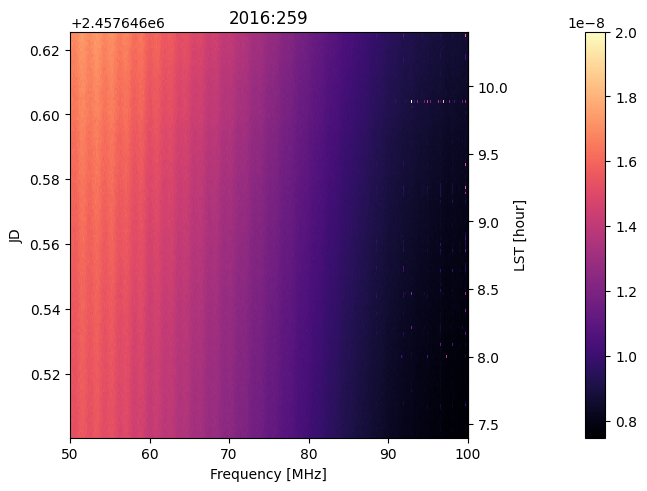

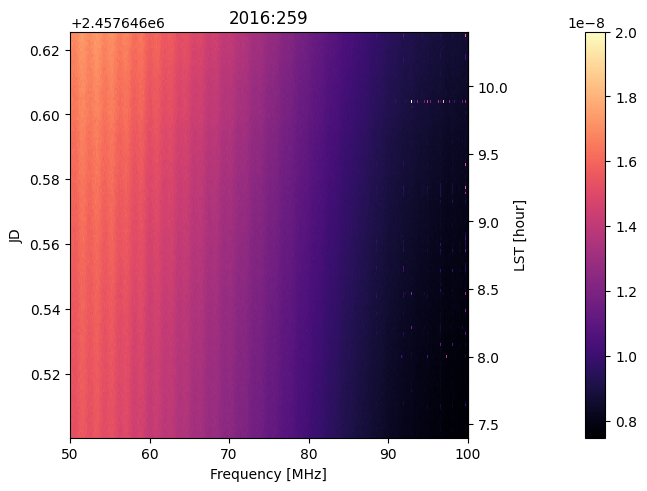

In [60]:
%matplotlib inline
plots.plot_waterfall(cut_data, vmax=2e-8);

By default, the waterfall will plot the first "load" (in this case, that is the measurement from the antenna). Remember that this is uncalibrated raw power. You can see some RFI above 90 MHz, and a ripple throughout the observation due to it not being calibrated.

## Constructing Your Own GSData Object

Now you know how to use a `GSData` object once you have one. But all of the above was based on directly reading a file that was already formatted in a way that `pygsdata` understands. I'm fairly certain that the data you have from your experiment is _not_ currently using `.gsh5` files as a standard file format.

Beyond that, perhaps you intend to use `GSData` for _simulated_ data, which doesn't need to be read from a file, but should be generated by some function in memory. 

`pygsdata` makes it (relatively) easy to construct your own `GSData` object from scratch. To do so, simply construct the object directly. You'll likely want to read the [API reference](https://pygsdata.readthedocs.io/en/latest/reference/index.html#pygsdata.GSData) to know what attributes need to be set explicitly, and which get sensible defaults.

But here we'll construct a _minimal_ example (i.e. not setting any non-required parameters):

In [61]:
ntimes = 100
nfreqs = 1000

my_own_data = pygsdata.GSData(
    telescope= pygsdata.Telescope(
        name='my-custom-telescope',
        location = EarthLocation.from_geodetic(lon=0*un.deg, lat=0*un.deg),
        pols=('xx',)
    ),
    data = np.ones((1,1, ntimes, nfreqs)),
    freqs = np.linspace(50, 100, nfreqs)*un.MHz,
    times = Time(np.linspace(2459861, 2459862, ntimes)[:, None], format='jd'),
)

In [62]:
print(my_own_data.data.shape)

(1, 1, 100, 1000)


## Making Your Own Data Reader

You can write your own data reader simply by writing a function that takes in a file in your experiment's format, and returning a manually constructed `GSData` object, as above. In fact, that is what we hope you will try to do in the next session.

However, you can do even better than that, integrating your reader into the `pygsdata` interface by decorating your reading function with the `gsdata_reader` decorator:

In [63]:
from pygsdata.readers import gsdata_reader

As a very simple example, imagine that you wrote your raw files in (heaven forbid) npz format. You might write your reader function like this:

In [64]:
@gsdata_reader(select_on_read=False, formats=['npz'])
def npz_reader(
    path: Path,
) -> pygsdata.GSData:
    data = np.load(path)
    
    return pygsdata.GSData(
        telescope = pygsdata.Telescope(
            name = 'my-telescope-that-writes-npz-files',
            location = EarthLocation.from_geodetic(lon=data['lon']*un.deg, lat=data['lat']*un.deg),
            pols=('xx',),
        ),
        data = data['data'],
        freqs = data['freqs'] * un.MHz,
        times = Time(data['times'], format='jd'),
        history = pygsdata.History(
            (
                pygsdata.Stamp(
                    "Read from npz file",
                    function="npz_reader",
                    parameters={"path": path},
                ),
            )
        ),
    )

Note here that the `gsdata_reader` decorator gets two arguments: the `select_on_read` argument tells `GSData` whether it's possible to pass selection parameters into the reader (i.e. to do partial reads). In this simple case, we always read the whole file, and can then down-select once the whole thing is read in.

The other is the `formats` argument, which tells `GSData` which file formats to associate with this reader. If you decorate your function this way, you can still simply call the function on your file, but ALSO you can use `GSData.from_file` and it will automatically use the function.

So, for example, let's write out some data that has the relevant attributes:

In [76]:
np.savez(
    results / "cut_data.npz",
    lon=cut_data.telescope.location.lon,
    lat = cut_data.telescope.location.lat,
    data = cut_data.data,
    freqs = cut_data.freqs.to_value("MHz"),
    times = cut_data.times.jd,
)

We can read the file directly:

In [78]:
cut_data_from_npz = npz_reader(results / 'cut_data.npz')

In [79]:
print(np.sum(cut_data_from_npz.data - cut_data.data))

0.0


But we can also use it now directly in `.from_file`:

In [80]:
cut_data_from_npz = pygsdata.GSData.from_file(results / "cut_data.npz")

Furthermore, in the `from_file` method, we have the ability to do down-selection directly on read:

In [81]:
pygsdata.GSData.from_file?

Signature:
pygsdata.GSData.from_file(
    filename: str | pathlib.Path,
    reader: str | None = None,
    selectors: dict[str, Any] | None = None,
    concat_axis: Literal['load', 'pol', 'time', 'freq'] | None = None,
    **kw,
) -> Self
Docstring:
Create a GSData instance from a file.

This method attempts to auto-detect the file type and read it.
File:      /data7/smurray/edges/workshop-notes/.venv/lib/python3.14/site-packages/pygsdata/gsdata.py
Type:      method

In [82]:
more_cut_data = pygsdata.GSData.from_file(results / "cut_data.npz", selectors = {"freq_selector": {"freq_range": (75*un.MHz, 95*un.MHz)}})

In [83]:
print(more_cut_data.freqs.min(), more_cut_data.freqs.max())

75.0 MHz 94.9951171875 MHz


Note that, in our case, this selection did not really do partial file reading, it just down-selected after reading. But it is a nice and convenient addition that you don't even have to write yourself!

## Wrap Up

In this brief whirlwind tutorial you've learnt to:

* Use `pygsdata` to read the native `.gsh5` files
* Access data and metadata from the object
* Select parts of the data
* Iterate through the data without needing to remember which axis corresponds to what
* Keep track of history and write functions that automatically track processing history
* Make simple waterfall plots of data
* Construct your own GSData object manually, and write a plugin data reader for your own data format.

There are a few more attributes/methods of the `GSData` object that we haven't covered yet -- in particular, the attributes that handle `flags` and those that handle model residuals. Since those are a bit more involved, and require some way of computing flags and models, we'll handle them in a different tutorial.